## CSC - 44112 
## ''Driver Behaviour Classification Using Smartphone Sensor Data With AI and ML''
## Student Id: 25043634
## Student Name: Moazzam Kiani
### Setup & Imports


In [1]:

# ============================================================
# CSC-44112 | Driver Behaviour Classification
# Section: Setup & Imports
# ============================================================
# These libraries cover the full workflow: data preparation, plotting,
# traditional machine learning, ANN training, and evaluation.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # Keep TensorFlow logging quieter.

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_auc_score)
from sklearn.inspection import permutation_importance

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")


All libraries imported successfully!
TensorFlow version: 2.21.0


In [2]:
# ============================================================
# Section: Output Folder Setup — Save All Plots as PNG
# ============================================================
# I keep the generated figures in one folder so they are easy to find later.
# Each saved plot goes there.
# This makes it simpler to add the figures to the report.
import os
plots_dir = 'report_figures'
os.makedirs(plots_dir, exist_ok=True)  # I used exist_ok=True so it won't crash if the folder already exists
print(f"All figures will be saved to: {os.path.abspath(plots_dir)}/")
print("Folder created and ready.")


All figures will be saved to: C:\Users\Z B O O K\OneDrive\Desktop\MONI's MODEL\MONI's MODEL (2)\MONI's MODEL\report_figures/
Folder created and ready.


## Section: Data Loading


In [3]:

# ============================================================
# Section: Data Loading
# ============================================================
# I load both labelled CSV files first and check their basic shape.
train_df = pd.read_csv('train_motion_data.csv')
test_df  = pd.read_csv('test_motion_data.csv')

print("Datasets loaded successfully!")
print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")

# I check the timestamp ranges before creating rolling features. The files come
# from separate recording sessions, so rolling calculations should be done on
# each file separately before the data is combined.
print("\n=== TIMESTAMP SESSION CHECK ===")
print(f"Train Timestamp range: {train_df['Timestamp'].min():,} -> {train_df['Timestamp'].max():,}")
print(f"Test  Timestamp range: {test_df['Timestamp'].min():,} -> {test_df['Timestamp'].max():,}")
print(f"Absolute gap between sessions: {abs(train_df['Timestamp'].min() - test_df['Timestamp'].max()):,} units")
print("\nConclusion: Train and Test are from separate recording sessions.")
print("Rolling statistics will be calculated separately before combining them.")

print("\n--- Train Data (first 10 rows) ---")
display(train_df.head(10))

print("\n--- Test Data (first 10 rows) ---")
display(test_df.head(10))


Datasets loaded successfully!
Train shape: (3644, 8)
Test shape:  (3084, 8)

=== TIMESTAMP SESSION CHECK ===
Train Timestamp range: 3,581,629 -> 3,583,791
Test  Timestamp range: 818,922 -> 820,709
Absolute gap between sessions: 2,760,920 units

Conclusion: Train and Test are from separate recording sessions.
Rolling statistics will be calculated separately before combining them.

--- Train Data (first 10 rows) ---


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.000000,0.000000,0.000000,0.059407,-0.174707,0.101938,NORMAL,3581629
1,-1.624864,-1.082492,-0.204183,-0.028558,0.051313,0.135536,NORMAL,3581630
2,-0.594660,-0.122410,0.220502,-0.019395,-0.029322,0.087888,NORMAL,3581630
3,0.738478,-0.228456,0.667732,0.069791,-0.029932,0.054902,NORMAL,3581631
4,0.101741,0.777568,-0.066730,0.030696,-0.003665,0.054902,NORMAL,3581631
5,0.158470,0.345891,0.355274,0.021533,0.115454,0.014584,NORMAL,3581632
6,0.078171,-0.349180,0.270652,0.034361,-0.030543,0.050625,NORMAL,3581632
7,-0.662750,-0.462775,-0.099797,0.008705,-0.009774,0.046960,NORMAL,3581633
8,0.467318,-0.234640,0.134139,-0.048717,-0.020769,-0.030009,NORMAL,3581633
9,-0.171895,-0.408894,0.414653,0.009316,0.058032,-0.019624,NORMAL,3581634



--- Test Data (first 10 rows) ---


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ,Class,Timestamp
0,0.758194,-0.217791,0.457263,0.000000,0.000000,0.000000,AGGRESSIVE,818922
1,0.667560,-0.038610,0.231416,-0.054367,-0.007712,0.225257,AGGRESSIVE,818923
2,2.724449,-7.584121,2.390926,0.023824,0.013668,-0.038026,AGGRESSIVE,818923
3,2.330950,-7.621754,2.529024,0.056810,-0.180587,-0.052076,AGGRESSIVE,818924
4,2.847215,-6.755621,2.224640,-0.031765,-0.035201,0.035277,AGGRESSIVE,818924
5,0.442229,-1.646833,0.065292,-0.010385,-0.024206,0.001069,AGGRESSIVE,818925
6,0.238391,0.029413,0.332829,0.001222,-0.015043,0.023060,AGGRESSIVE,818925
7,0.043449,0.228911,0.354669,0.070250,0.050320,0.077427,AGGRESSIVE,818926
8,-0.095364,-0.027441,-0.039780,0.040928,-0.010156,0.136681,AGGRESSIVE,818926
9,0.270520,-0.073730,0.003035,0.003665,-0.007712,0.257632,AGGRESSIVE,818927


## Section: Initial Data Inspection


In [4]:
# ============================================================
# Section: Initial Data Inspection
# ============================================================
# I start with the basic data checks: types, missing values, class balance,
# duplicates, and timestamp order.
print("=== TRAIN DATA TYPES & NON-NULL COUNTS ===")
print(train_df.info())
print("\n=== MISSING VALUES IN TRAIN ===")
print(train_df.isnull().sum())
print("\n=== MISSING VALUES IN TEST ===")
print(test_df.isnull().sum())
print("\n=== CLASS DISTRIBUTION (TRAIN) ===")
print(train_df['Class'].value_counts())
print("\n=== CLASS DISTRIBUTION (TEST) ===")
print(test_df['Class'].value_counts())
# I checked for exact duplicate rows — duplicates in sensor data can silently
# so I check for them before modelling.
train_dups = train_df.duplicated().sum()
test_dups  = test_df.duplicated().sum()
print(f"\nDuplicate rows in Train: {train_dups}")
print(f"Duplicate rows in Test:  {test_dups}")
if train_dups > 0:
    print("I will drop these before proceeding.")
    train_df = train_df.drop_duplicates()
else:
    print("No duplicates found — I can proceed cleanly.")

# I also check whether each file is still in time order.
print(f"\nTrain Timestamp monotonically increasing: {train_df['Timestamp'].is_monotonic_increasing}")
print(f"Test  Timestamp monotonically increasing: {test_df['Timestamp'].is_monotonic_increasing}")


=== TRAIN DATA TYPES & NON-NULL COUNTS ===
<class 'pandas.DataFrame'>
RangeIndex: 3644 entries, 0 to 3643
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   AccX       3644 non-null   float64
 1   AccY       3644 non-null   float64
 2   AccZ       3644 non-null   float64
 3   GyroX      3644 non-null   float64
 4   GyroY      3644 non-null   float64
 5   GyroZ      3644 non-null   float64
 6   Class      3644 non-null   str    
 7   Timestamp  3644 non-null   int64  
dtypes: float64(6), int64(1), str(1)
memory usage: 227.9 KB
None

=== MISSING VALUES IN TRAIN ===
AccX         0
AccY         0
AccZ         0
GyroX        0
GyroY        0
GyroZ        0
Class        0
Timestamp    0
dtype: int64

=== MISSING VALUES IN TEST ===
AccX         0
AccY         0
AccZ         0
GyroX        0
GyroY        0
GyroZ        0
Class        0
Timestamp    0
dtype: int64

=== CLASS DISTRIBUTION (TRAIN) ===
Class
SLOW          1331
NORMA

## Section: EDA — Data Cleaning & Descriptive Statistics


In [5]:

# ============================================================
# Section: EDA - Data Cleaning & Descriptive Statistics
# ============================================================
# Timestamp only records order, not driving behaviour, so I remove it before modelling.
train_df = train_df.drop(columns=['Timestamp'])
test_df  = test_df.drop(columns=['Timestamp'])

print("Timestamp dropped.")
print("\n=== DESCRIPTIVE STATISTICS (TRAIN) ===")
display(train_df.describe().round(3))

# The per-class statistics show why raw readings are not enough on their own.
# The class means are very close, so the model needs temporal features later.
print("\n=== PER-CLASS MEAN VALUES (TRAIN) ===")
print("If these means are nearly identical across classes, raw features won't work alone.\n")
display(train_df.groupby('Class')[['AccX','AccY','AccZ','GyroX','GyroY','GyroZ']].mean().round(4))

print("\n=== PER-CLASS STANDARD DEVIATIONS (TRAIN) ===")
print("Standard deviation differences across classes matter more than mean differences here.\n")
display(train_df.groupby('Class')[['AccX','AccY','AccZ','GyroX','GyroY','GyroZ']].std().round(4))


Timestamp dropped.

=== DESCRIPTIVE STATISTICS (TRAIN) ===


,AccX,AccY,AccZ,GyroX,GyroY,GyroZ
count,3644.000,3644.000,3644.000,3644.000,3644.000,3644.000
mean,0.040,-0.073,0.008,0.002,-0.001,0.008
std,0.986,0.903,0.985,0.067,0.126,0.116
min,-4.637,-4.700,-7.144,-0.752,-1.587,-1.236
25%,-0.551,-0.593,-0.558,-0.029,-0.054,-0.029
50%,0.004,-0.081,0.002,0.002,-0.002,0.003
75%,0.596,0.452,0.556,0.032,0.051,0.041
max,4.986,4.245,5.172,0.849,1.680,1.190



=== PER-CLASS MEAN VALUES (TRAIN) ===
If these means are nearly identical across classes, raw features won't work alone.



,AccX,AccY,AccZ,GyroX,GyroY,GyroZ
Class,,,,,,
AGGRESSIVE,0.0961,-0.1705,-0.0211,0.0002,-0.0029,0.0111
NORMAL,-0.0180,-0.0277,0.0344,0.0019,-0.0009,0.0095
SLOW,0.0466,-0.0335,0.0093,0.0025,-0.0002,0.0039



=== PER-CLASS STANDARD DEVIATIONS (TRAIN) ===
Standard deviation differences across classes matter more than mean differences here.



,AccX,AccY,AccZ,GyroX,GyroY,GyroZ
Class,,,,,,
AGGRESSIVE,1.2183,1.1387,1.1292,0.0717,0.1359,0.1311
NORMAL,0.8662,0.8144,0.9645,0.0607,0.1175,0.1138
SLOW,0.8590,0.7364,0.8671,0.0681,0.1254,0.1030


## Section: EDA — Class Distribution Visualisation


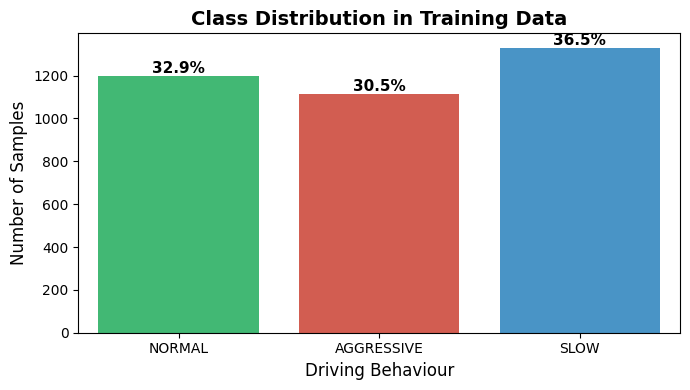

Plot saved.


In [6]:
# ============================================================
# Section: EDA — Class Distribution Visualisation
# ============================================================
# I plot the class distribution with percentages so the balance is clear.
plt.figure(figsize=(7, 4))
ax = sns.countplot(data=train_df, x='Class',
              hue='Class',
              palette=['#2ecc71', '#e74c3c', '#3498db'],
              order=['NORMAL', 'AGGRESSIVE', 'SLOW'],
              legend=False)
# The labels make the class proportions easier to read.
total = len(train_df)
for p in ax.patches:
    pct = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(pct,
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.title('Class Distribution in Training Data', fontsize=14, fontweight='bold')
plt.xlabel('Driving Behaviour', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("Plot saved.")


## Section: EDA — Feature Distributions by Class


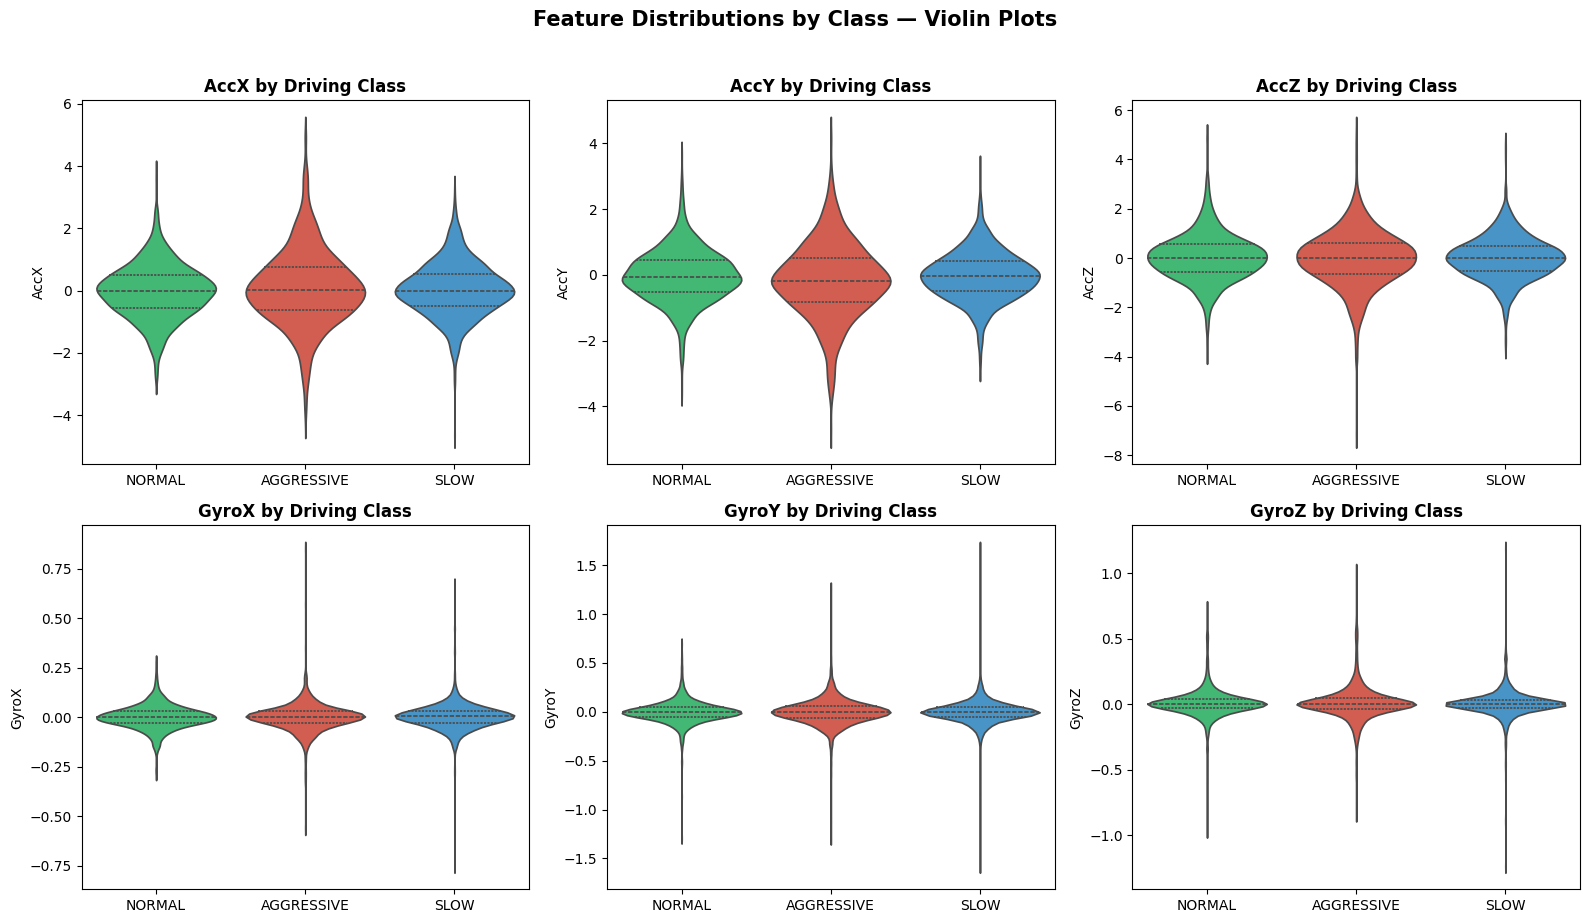

Plot saved.


In [7]:
# ============================================================
# Section: EDA — Feature Distributions by Class
# ============================================================
# Violin plots show the spread, centre, and shape of each feature by class.
# shape, the median, and the spread all at once — much more informative than
features_raw = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, feature in enumerate(features_raw):
    sns.violinplot(data=train_df, x='Class', y=feature,
                   hue='Class',
                   order=['NORMAL', 'AGGRESSIVE', 'SLOW'],
                   palette=['#2ecc71', '#e74c3c', '#3498db'],
                   inner='quartile',   # I added quartile lines inside the violin
                   ax=axes[i],
                   legend=False)
    axes[i].set_title(f'{feature} by Driving Class', fontweight='bold')
    axes[i].set_xlabel('')
plt.suptitle('Feature Distributions by Class — Violin Plots',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150)
plt.show()
print("Plot saved.")


## Section: EDA — Boxplots for Outlier Detection


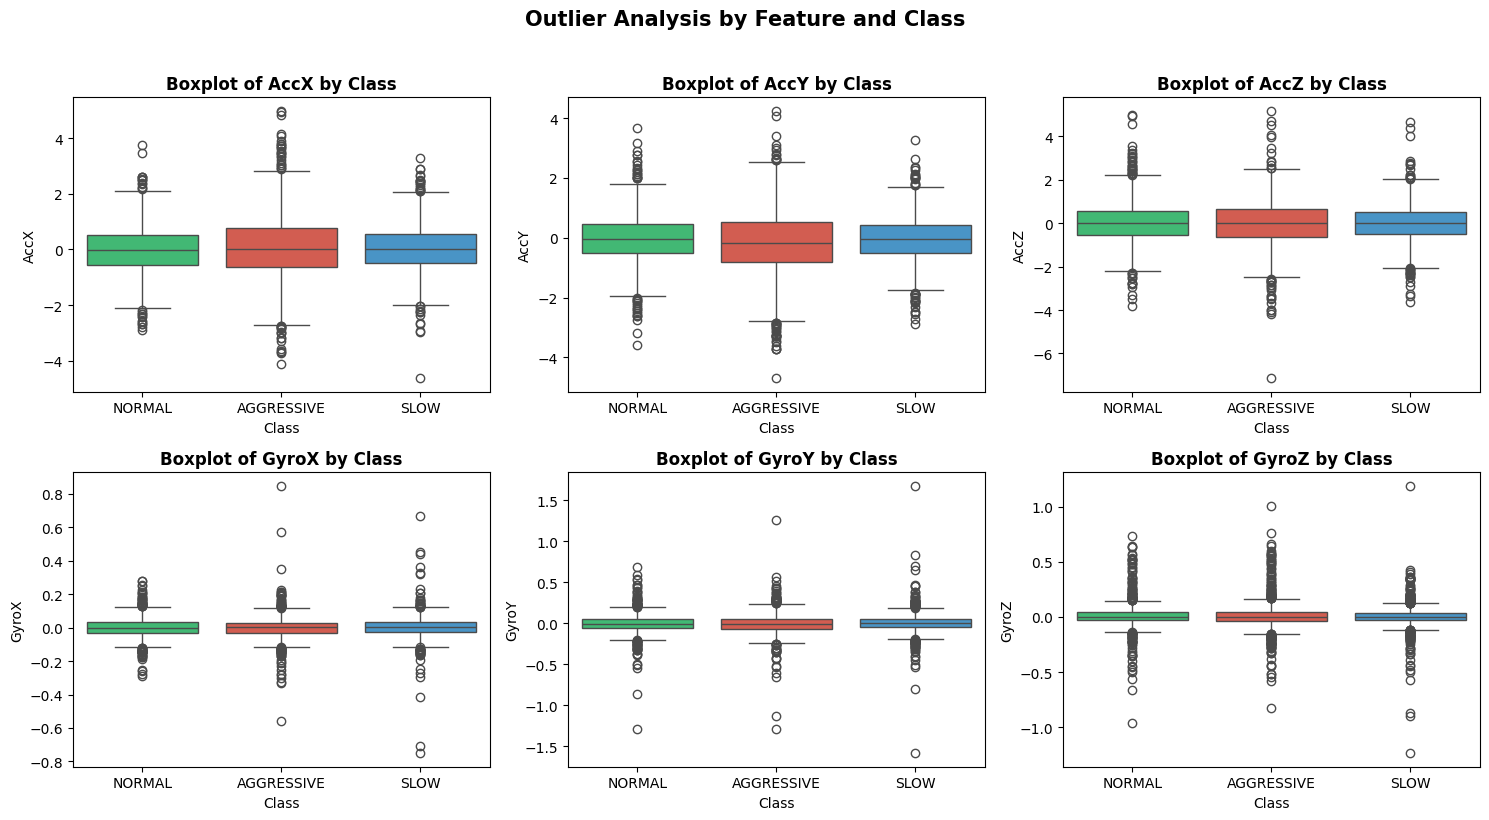

Boxplot saved.

=== OUTLIER COUNT PER FEATURE PER CLASS (IQR Method) ===
A reading is an outlier if it falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR



Class,AGGRESSIVE,NORMAL,SLOW
Feature,,,
AccX,3.77,2.08,2.25
AccY,3.50,3.08,2.85
AccZ,3.05,3.42,2.48
GyroX,6.47,5.50,4.28
GyroY,5.30,6.58,6.84
GyroZ,12.49,9.25,11.04



Values show % of samples that are outliers per feature per class.
I kept AGGRESSIVE class outliers — they represent genuine hard-driving events.


In [8]:
# ============================================================
# Section: EDA — Boxplots for Outlier Detection
# ============================================================
# Boxplots give a quick check for extreme sensor readings.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, feature in enumerate(features_raw):
    sns.boxplot(data=train_df, x='Class', y=feature, ax=axes[i],
                hue='Class',
                palette=['#2ecc71', '#e74c3c', '#3498db'],
                order=['NORMAL', 'AGGRESSIVE', 'SLOW'],
                legend=False)
    axes[i].set_title(f'Boxplot of {feature} by Class', fontweight='bold')
plt.suptitle('Outlier Analysis by Feature and Class',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150)
plt.show()
print("Boxplot saved.")
# I keep aggressive-class outliers because they can represent real harsh events,
# not measurement errors.
# I use the IQR method to count those extreme readings more formally.
print("\n=== OUTLIER COUNT PER FEATURE PER CLASS (IQR Method) ===")
print("A reading is an outlier if it falls below Q1 - 1.5*IQR or above Q3 + 1.5*IQR\n")
outlier_summary = []
for cls in ['NORMAL', 'AGGRESSIVE', 'SLOW']:
    subset = train_df[train_df['Class'] == cls]
    for feat in features_raw:
        Q1  = subset[feat].quantile(0.25)
        Q3  = subset[feat].quantile(0.75)
        IQR = Q3 - Q1
        n_out = ((subset[feat] < Q1 - 1.5*IQR) | (subset[feat] > Q3 + 1.5*IQR)).sum()
        outlier_summary.append({'Class': cls, 'Feature': feat, 'Outliers': n_out,
                                  'Outlier %': round(100*n_out/len(subset), 2)})
outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.pivot(index='Feature', columns='Class', values='Outlier %'))
print("\nValues show % of samples that are outliers per feature per class.")
print("I kept AGGRESSIVE class outliers — they represent genuine hard-driving events.")


## Section: EDA — Correlation Heatmap


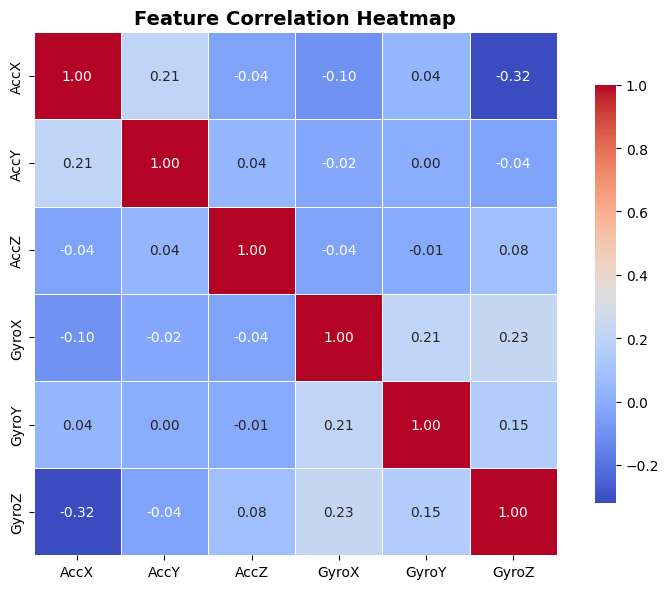


=== KEY CORRELATION FINDING ===
Top 3 feature correlations:
AccX   GyroZ    0.316
GyroX  GyroZ    0.229
GyroY  GyroX    0.210
dtype: float64

Conclusion: All 6 raw features are largely independent of each other.
The strongest correlation is AccX↔GyroZ at ~-0.32.
This tells me dimensionality reduction would discard unique information,
so I will keep all 6 features going into engineering.


In [9]:
# ============================================================
# Section: EDA — Correlation Heatmap
# ============================================================
# The correlation matrix shows how much the raw features move together.
plt.figure(figsize=(8, 6))
corr = train_df[features_raw].corr().round(2)
sns.heatmap(corr, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5,
            square=True, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
# I print the strongest correlations so the plot has a clear takeaway.
print("\n=== KEY CORRELATION FINDING ===")
corr = train_df[features_raw].corr()
max_corr = corr.abs().unstack().sort_values(ascending=False)
max_corr = max_corr[max_corr < 1.0].drop_duplicates()
print("Top 3 feature correlations:")
print(max_corr.head(3).round(3))
print("\nConclusion: All 6 raw features are largely independent of each other.")
print("The strongest correlation is AccX↔GyroZ at ~-0.32.")
print("This tells me dimensionality reduction would discard unique information,")
print("so I will keep all 6 features going into engineering.")


## Section: EDA — Pairplot for Class Separability


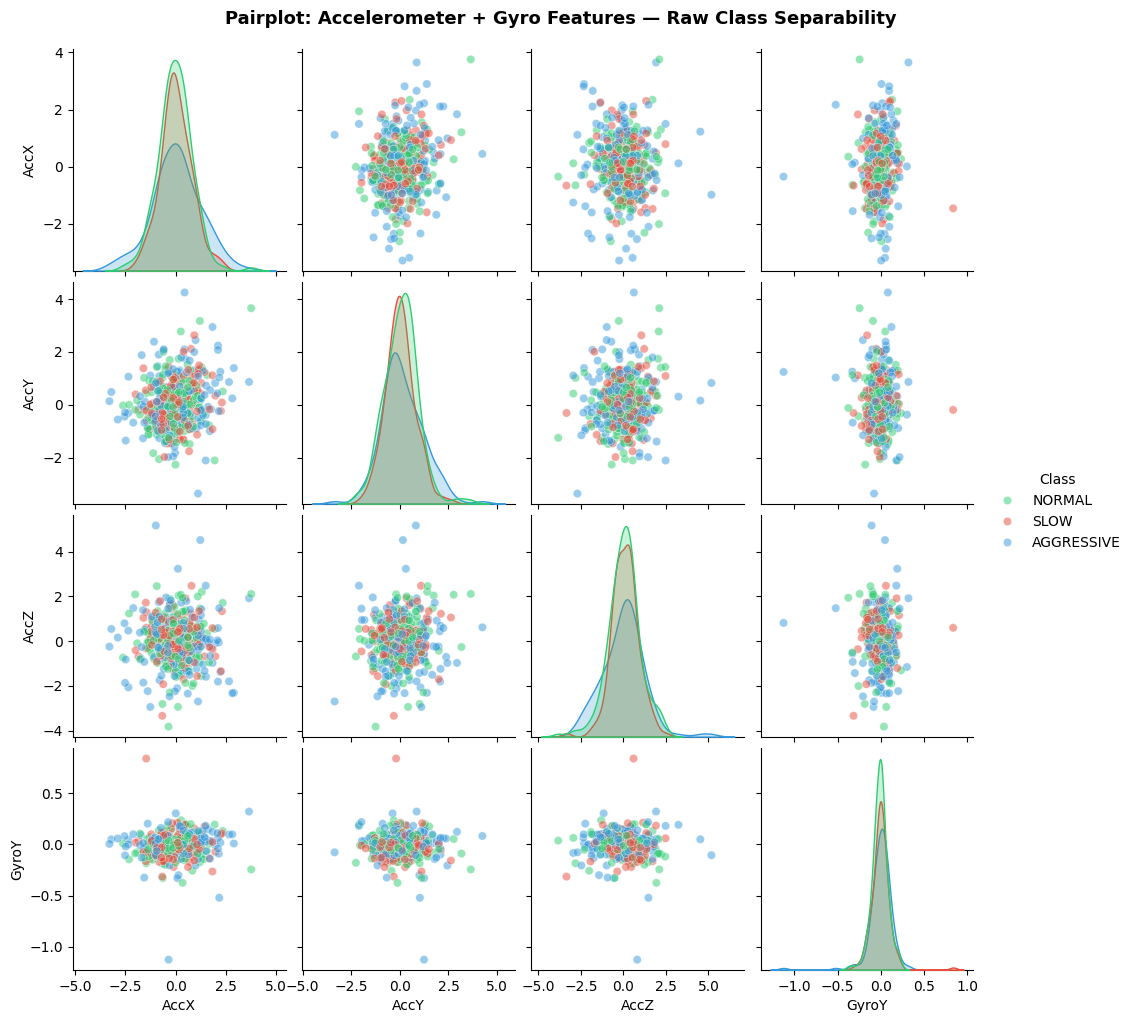

Plot saved.


In [10]:
# ============================================================
# Section: EDA — Pairplot for Class Separability
# ============================================================
# I sample 500 rows so the pairplot stays readable and quick to draw.
# The plot gives a visual check of class separation in two dimensions.
sample_df = train_df.sample(500, random_state=42)
sns.pairplot(sample_df, hue='Class',
             vars=['AccX', 'AccY', 'AccZ', 'GyroY'],
# I include GyroY to compare accelerometer separation with a weaker gyro feature.
# This supports using rolling statistics instead of relying only on raw readings.
             palette=['#2ecc71', '#e74c3c', '#3498db'],
             plot_kws={'alpha': 0.5})
plt.suptitle('Pairplot: Accelerometer + Gyro Features — Raw Class Separability',
             y=1.02, fontsize=13, fontweight='bold')
plt.savefig('pairplot.png', dpi=150)
plt.show()
print("Plot saved.")


## Section: Feature Engineering


In [11]:
# ============================================================
# Feature Engineering — Step 1: Magnitude Features
# ============================================================
# Magnitude features capture total motion intensity regardless of direction.
# Braking or turning can affect several axes at once, so a combined signal
# axes simultaneously — magnitude collapses all three into one signal.
# Accelerometer magnitude — total force experienced
train_df['Acc_magnitude'] = np.sqrt(train_df['AccX']**2 +
                                     train_df['AccY']**2 +
                                     train_df['AccZ']**2)
test_df['Acc_magnitude']  = np.sqrt(test_df['AccX']**2 +
                                     test_df['AccY']**2 +
                                     test_df['AccZ']**2)
# Gyroscope magnitude — total rotational intensity
train_df['Gyro_magnitude'] = np.sqrt(train_df['GyroX']**2 +
                                      train_df['GyroY']**2 +
                                      train_df['GyroZ']**2)
test_df['Gyro_magnitude']  = np.sqrt(test_df['GyroX']**2 +
                                      test_df['GyroY']**2 +
                                      test_df['GyroZ']**2)
print("Magnitude features created.")
print(f"Train shape: {train_df.shape} | Test shape: {test_df.shape}")


Magnitude features created.
Train shape: (3644, 9) | Test shape: (3084, 9)


In [12]:

# ============================================================
# Feature Engineering - Step 2: Jerk Features
# ============================================================
# Jerk captures sudden changes in acceleration, which is useful for detecting
# harsh braking, sharp movement, or aggressive driving patterns.
for df in [train_df, test_df]:
    df['Jerk_X'] = df['AccX'].diff().fillna(0)
    df['Jerk_Y'] = df['AccY'].diff().fillna(0)
    df['Jerk_Z'] = df['AccZ'].diff().fillna(0)

    # Total jerk combines the three acceleration axes into one movement signal.
    df['Jerk_magnitude'] = np.sqrt(df['Jerk_X']**2 +
                                    df['Jerk_Y']**2 +
                                    df['Jerk_Z']**2)

# This quick check shows whether aggressive samples have larger jerk values.
print("=== JERK MAGNITUDE - PER CLASS MEAN (TRAIN) ===")
print("AGGRESSIVE class should show significantly higher jerk than NORMAL/SLOW\n")
display(train_df.groupby('Class')[['Jerk_X','Jerk_Y','Jerk_Z','Jerk_magnitude']].mean().round(4))


=== JERK MAGNITUDE - PER CLASS MEAN (TRAIN) ===
AGGRESSIVE class should show significantly higher jerk than NORMAL/SLOW



,Jerk_X,Jerk_Y,Jerk_Z,Jerk_magnitude
Class,,,,
AGGRESSIVE,-0.0001,-0.0012,-0.0004,1.9988
NORMAL,0.0005,0.0010,-0.0006,1.7536
SLOW,-0.0007,0.0004,0.0006,1.6445


In [13]:

# ============================================================
# Feature Engineering - Step 3: Rolling Window Statistics
# ============================================================
# Rolling features are calculated separately for each original file. This keeps
# one recording session from bleeding into another when the datasets are combined.
window = 10

# A 10-reading window is long enough to capture a short driving event while
# still keeping sudden changes visible.
sensor_cols = ['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ',
               'Acc_magnitude', 'Gyro_magnitude']

for df_name, df in [('train', train_df), ('test', test_df)]:
    for col in sensor_cols:
        # Average motion over the window.
        df[f'{col}_rmean'] = df[col].rolling(window, min_periods=1).mean()

        # Variability over the window.
        df[f'{col}_rstd']  = df[col].rolling(window, min_periods=1).std().fillna(0)

        # Peak value inside the window.
        df[f'{col}_rmax']  = df[col].rolling(window, min_periods=1).max()

        # Short-term swing between the highest and lowest values.
        df[f'{col}_rrange'] = (df[col].rolling(window, min_periods=1).max() -
                                df[col].rolling(window, min_periods=1).min())

    print(f"{df_name} shape after rolling features: {df.shape}")

print(f"\nTotal features after all engineering: {train_df.shape[1]}")


train shape after rolling features: (3644, 45)
test shape after rolling features: (3084, 45)

Total features after all engineering: 45


=== RAW FEATURE: AccX — Per-Class Std ===
Class
AGGRESSIVE    1.2183
NORMAL        0.8662
SLOW          0.8590
Name: AccX, dtype: float64

=== ENGINEERED: AccX_rstd — Per-Class Mean ===
A bigger gap between classes here = more discriminative power

Class
AGGRESSIVE    1.0021
NORMAL        0.7526
SLOW          0.7392
Name: AccX_rstd, dtype: float64

=== ENGINEERED: Jerk_magnitude — Per-Class Mean ===
Class
AGGRESSIVE    1.9988
NORMAL        1.7536
SLOW          1.6445
Name: Jerk_magnitude, dtype: float64


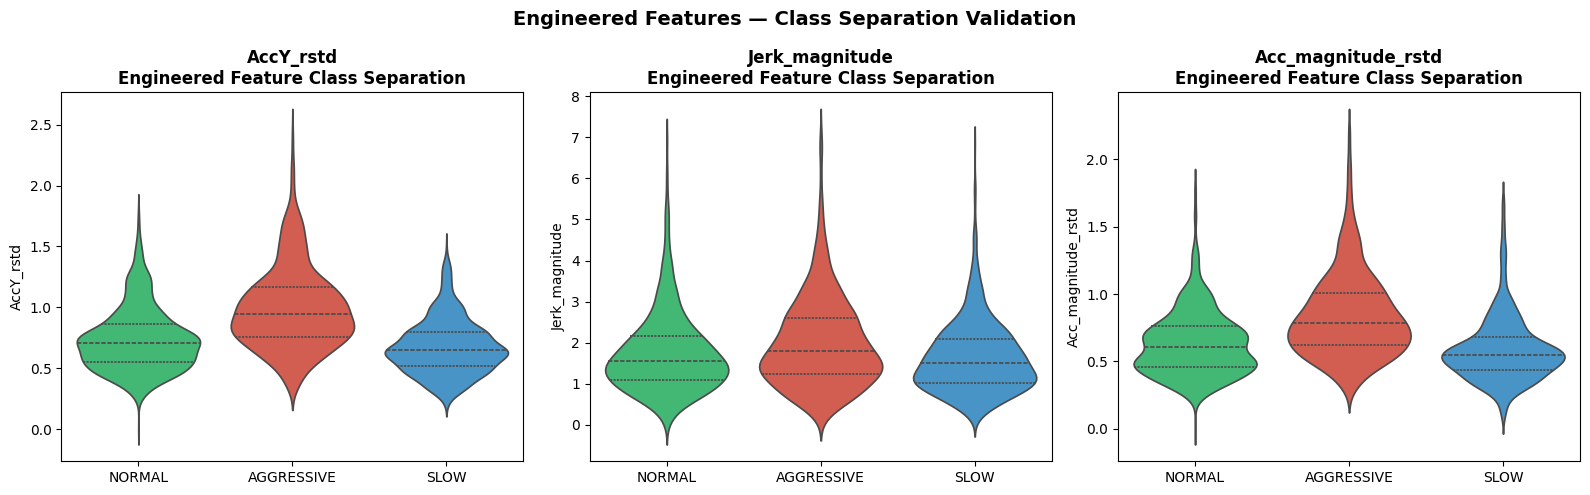

Validation plot saved.


In [14]:
# ============================================================
# Feature Engineering — Step 4: Validation
# ============================================================
# I compare engineered features with raw features to check whether the
# new inputs actually improve class separation.
print("=== RAW FEATURE: AccX — Per-Class Std ===")
print(train_df.groupby('Class')['AccX'].std().round(4))
print("\n=== ENGINEERED: AccX_rstd — Per-Class Mean ===")
print("A bigger gap between classes here = more discriminative power\n")
print(train_df.groupby('Class')['AccX_rstd'].mean().round(4))
print("\n=== ENGINEERED: Jerk_magnitude — Per-Class Mean ===")
print(train_df.groupby('Class')['Jerk_magnitude'].mean().round(4))
# I also plot a few of the strongest engineered features.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feature in zip(axes, ['AccY_rstd', 'Jerk_magnitude', 'Acc_magnitude_rstd']):
    sns.violinplot(data=train_df, x='Class', y=feature,
                   hue='Class',
                   order=['NORMAL', 'AGGRESSIVE', 'SLOW'],
                   palette=['#2ecc71', '#e74c3c', '#3498db'],
                   inner='quartile',
                   ax=ax, legend=False)
    ax.set_title(f'{feature}\nEngineered Feature Class Separation', fontweight='bold')
    ax.set_xlabel('')
plt.suptitle('Engineered Features — Class Separation Validation',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('engineered_feature_validation.png', dpi=150)
plt.show()
print("Validation plot saved.")


In [15]:
# ============================================================
# Feature Engineering — Summary
# ============================================================
# This summary keeps track of the final feature set.
raw_features       = ['AccX','AccY','AccZ','GyroX','GyroY','GyroZ']
magnitude_features = ['Acc_magnitude','Gyro_magnitude']
jerk_features      = ['Jerk_X','Jerk_Y','Jerk_Z','Jerk_magnitude']
rolling_features   = [c for c in train_df.columns
                      if any(s in c for s in ['_rmean','_rstd','_rmax','_rrange'])]
print("=== FEATURE ENGINEERING SUMMARY ===\n")
print(f"Raw sensor features:       {len(raw_features)}   → AccX through GyroZ")
print(f"Magnitude features:        {len(magnitude_features)}   → Acc_magnitude, Gyro_magnitude")
print(f"Jerk features:             {len(jerk_features)}   → Rate of change of acceleration")
print(f"Rolling window features:   {len(rolling_features)}  → Window=10: mean, std, max, range")
print(f"{'─'*45}")
print(f"Total features for models: {len(raw_features)+len(magnitude_features)+len(jerk_features)+len(rolling_features)}")
print(f"\nTrain shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
# I store the feature list once so every model uses the same inputs.
all_features = raw_features + magnitude_features + jerk_features + rolling_features
print(f"\nall_features list is ready — {len(all_features)} features total.")


=== FEATURE ENGINEERING SUMMARY ===

Raw sensor features:       6   → AccX through GyroZ
Magnitude features:        2   → Acc_magnitude, Gyro_magnitude
Jerk features:             4   → Rate of change of acceleration
Rolling window features:   32  → Window=10: mean, std, max, range
─────────────────────────────────────────────
Total features for models: 44

Train shape: (3644, 45)
Test shape:  (3084, 45)

all_features list is ready — 44 features total.


## Section: Preprocessing — Feature Selection


In [16]:
# ============================================================
# Section: Preprocessing - Combine Data and Create Final 80/20 Split
# ============================================================
# Since both files are labelled, I combine them after feature engineering.
# The rolling features were already created separately, so the combined split
# does not mix windows across recording sessions.
exclude_cols = ['Class', 'Timestamp']
all_features = [c for c in train_df.columns if c not in exclude_cols]
combined_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)
combined_df = combined_df.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Combined labelled samples: {combined_df.shape[0]}")
print(f"I'm using {len(all_features)} features for all models:")
print(all_features)
# I use a stratified 80/20 split so each class keeps a similar proportion
# in training and validation/test data.
X = combined_df[all_features]
y = combined_df['Class']
X_train, X_test_internal, y_train, y_test_internal = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y, shuffle=True
)
print(f"Training samples:      {X_train.shape[0]}")
print(f"Validation/test samples:{X_test_internal.shape[0]}")
print("\nClass distribution in training set:")
print(y_train.value_counts())
print("\nClass distribution in validation/test set:")
print(y_test_internal.value_counts())
# The label encoder is fitted on the training labels.
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test_internal)
# I print the label mapping so the reports are easier to read.
print("\nClass encoding I applied:")
for cls, idx in zip(le.classes_, le.transform(le.classes_)):
    print(f"  {cls} -> {idx}")
# I standardise the features before modelling.
# KNN needs comparable feature scales for distance calculations.
# ANN training is also more stable with scaled inputs.
# Random Forest does not require scaling, but one scaled matrix keeps
# the comparison consistent.
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test_internal)
print("Scaling applied. Feature means are now ~0, standard deviations ~1.")
print(f"Example - AccX mean after scaling: {X_train_sc[:,0].mean():.4f}")
print(f"Example - AccX std after scaling:  {X_train_sc[:,0].std():.4f}")


Combined labelled samples: 6728
I'm using 44 features for all models:
['AccX', 'AccY', 'AccZ', 'GyroX', 'GyroY', 'GyroZ', 'Acc_magnitude', 'Gyro_magnitude', 'Jerk_X', 'Jerk_Y', 'Jerk_Z', 'Jerk_magnitude', 'AccX_rmean', 'AccX_rstd', 'AccX_rmax', 'AccX_rrange', 'AccY_rmean', 'AccY_rstd', 'AccY_rmax', 'AccY_rrange', 'AccZ_rmean', 'AccZ_rstd', 'AccZ_rmax', 'AccZ_rrange', 'GyroX_rmean', 'GyroX_rstd', 'GyroX_rmax', 'GyroX_rrange', 'GyroY_rmean', 'GyroY_rstd', 'GyroY_rmax', 'GyroY_rrange', 'GyroZ_rmean', 'GyroZ_rstd', 'GyroZ_rmax', 'GyroZ_rrange', 'Acc_magnitude_rmean', 'Acc_magnitude_rstd', 'Acc_magnitude_rmax', 'Acc_magnitude_rrange', 'Gyro_magnitude_rmean', 'Gyro_magnitude_rstd', 'Gyro_magnitude_rmax', 'Gyro_magnitude_rrange']
Training samples:      5382
Validation/test samples:1346

Class distribution in training set:
Class
SLOW          2083
NORMAL        1757
AGGRESSIVE    1542
Name: count, dtype: int64

Class distribution in validation/test set:
Class
SLOW          521
NORMAL        44

## Section: Model 1 — Logistic Regression


In [17]:

# ============================================================
# Section: Model 1 - Logistic Regression (Linear Baseline)
# ============================================================
# Logistic Regression is used as a simple baseline. If it performs poorly, that
# supports the EDA finding that the class boundaries are not mostly linear.
lr_model = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr_model.fit(X_train_sc, y_train_enc)
lr_preds = lr_model.predict(X_test_sc)
lr_acc   = accuracy_score(y_test_enc, lr_preds)

print(f"Logistic Regression Test Accuracy: {lr_acc*100:.2f}%")
print("\n=== Classification Report ===")
print(classification_report(y_test_enc, lr_preds, target_names=le.classes_))

# I check convergence so the reported score is not based on an unfinished fit.
print(f"Convergence achieved: {lr_model.n_iter_[0] < 1000}")
print(f"Iterations used: {lr_model.n_iter_[0]}/1000")


Logistic Regression Test Accuracy: 54.75%

=== Classification Report ===
              precision    recall  f1-score   support

  AGGRESSIVE       0.67      0.63      0.65       385
      NORMAL       0.43      0.24      0.31       440
        SLOW       0.53      0.74      0.62       521

    accuracy                           0.55      1346
   macro avg       0.54      0.54      0.53      1346
weighted avg       0.54      0.55      0.53      1346

Convergence achieved: True
Iterations used: 108/1000


## Section: Model 2 — K-Nearest Neighbours


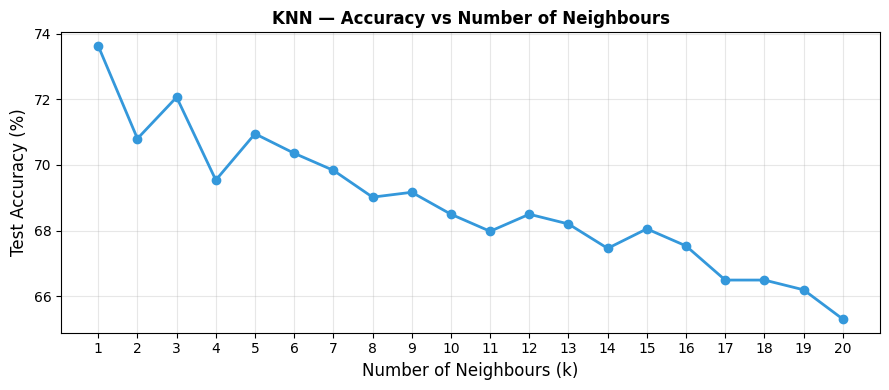

Best k found: 1 with accuracy 73.63%

Final KNN Accuracy (k=1): 73.63%

=== Classification Report ===
              precision    recall  f1-score   support

  AGGRESSIVE       0.82      0.73      0.77       385
      NORMAL       0.69      0.69      0.69       440
        SLOW       0.72      0.78      0.75       521

    accuracy                           0.74      1346
   macro avg       0.74      0.73      0.74      1346
weighted avg       0.74      0.74      0.74      1346



In [18]:
# ============================================================
# Section: Model 2 — K-Nearest Neighbours
# ============================================================
# I chose KNN because it makes no assumptions about the data distribution —
# it classifies purely by proximity in the 44-dimensional scaled feature space.
# Unlike Logistic Regression, it can capture non-linear boundaries, but unlike
# Random Forest it has no way to learn which features actually matter.
# I ran a quick k-selection loop to find the best number of neighbours
# rather than assuming k=5 is optimal
k_range    = range(1, 21)
k_scores   = []
for k in k_range:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_sc, y_train_enc)
    k_scores.append(accuracy_score(y_test_enc, knn_temp.predict(X_test_sc)))
# I plot the k vs accuracy curve to visually pick the elbow point
plt.figure(figsize=(9, 4))
plt.plot(k_range, [s*100 for s in k_scores],
         marker='o', color='#3498db', linewidth=2)
plt.xlabel('Number of Neighbours (k)', fontsize=12)
plt.ylabel('Test Accuracy (%)', fontsize=12)
plt.title('KNN — Accuracy vs Number of Neighbours', fontweight='bold')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('knn_k_selection.png', dpi=150)
plt.show()
# I select the best k from the accuracy scores.
best_k   = k_range[k_scores.index(max(k_scores))]
print(f"Best k found: {best_k} with accuracy {max(k_scores)*100:.2f}%")
# I train the final KNN model using the best k
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_sc, y_train_enc)
knn_preds = knn_model.predict(X_test_sc)
knn_acc   = accuracy_score(y_test_enc, knn_preds)
print(f"\nFinal KNN Accuracy (k={best_k}): {knn_acc*100:.2f}%")
print("\n=== Classification Report ===")
print(classification_report(y_test_enc, knn_preds, target_names=le.classes_))


## Section: Model 3 — Random Forest Classifier


In [19]:

# ============================================================
# Section: Model 3 - Random Forest (Tuned with Grid Search)
# ============================================================
# Random Forest is a strong fit for this dataset because it handles non-linear
# boundaries, tolerates noisy sensor readings, and gives feature importance.
# I tune max_features as well because the model now has 44 engineered inputs.
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2']
}

print("Running Grid Search - 36 combinations x 5 folds = 180 fits.")
print("This will take 3-5 minutes...\n")

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_sc, y_train_enc)

print(f"\nBest Parameters I found:  {grid_search.best_params_}")
print(f"Best CV Accuracy:         {grid_search.best_score_*100:.2f}%")

best_rf       = grid_search.best_estimator_
best_rf_preds = best_rf.predict(X_test_sc)
best_rf_acc   = accuracy_score(y_test_enc, best_rf_preds)

print(f"Best RF Test Accuracy:    {best_rf_acc*100:.2f}%")
print("\n=== Classification Report ===")
print(classification_report(y_test_enc, best_rf_preds, target_names=le.classes_))


Running Grid Search - 36 combinations x 5 folds = 180 fits.
This will take 3-5 minutes...

Fitting 5 folds for each of 36 candidates, totalling 180 fits



Best Parameters I found:  {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Best CV Accuracy:         90.97%
Best RF Test Accuracy:    92.94%

=== Classification Report ===
              precision    recall  f1-score   support

  AGGRESSIVE       0.97      0.91      0.94       385
      NORMAL       0.96      0.89      0.92       440
        SLOW       0.89      0.98      0.93       521

    accuracy                           0.93      1346
   macro avg       0.94      0.93      0.93      1346
weighted avg       0.93      0.93      0.93      1346



Computing permutation importance — this takes about 1 minute...


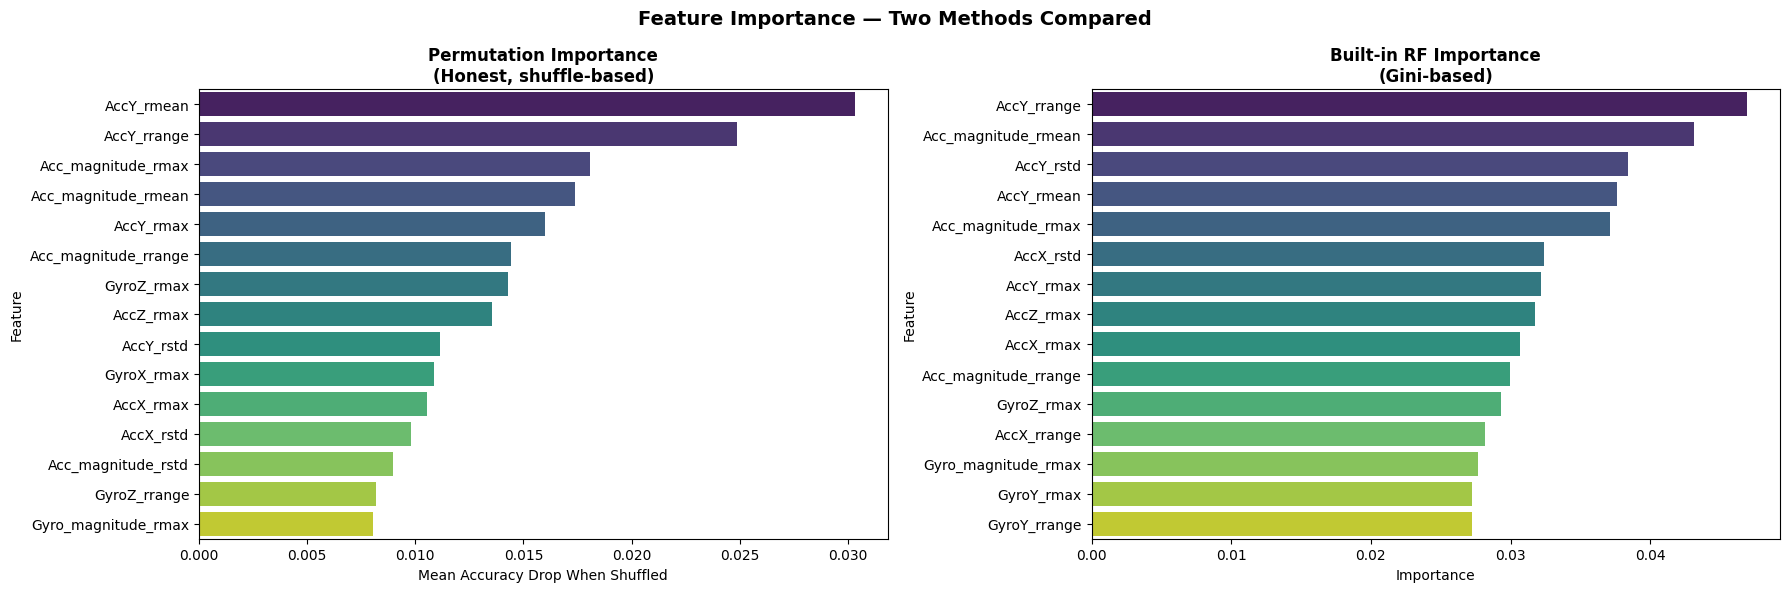


Top 5 features by permutation importance:
            Feature  Importance      Std
         AccY_rmean    0.030312 0.003970
        AccY_rrange    0.024889 0.003628
 Acc_magnitude_rmax    0.018053 0.004097
Acc_magnitude_rmean    0.017385 0.002662
          AccY_rmax    0.015973 0.003733


In [20]:
# ============================================================
# Section: Random Forest — Permutation Importance
# ============================================================
# I use permutation importance alongside built-in feature importance
# because built-in RF importance can overrate features with many unique values.
# Permutation importance works by shuffling one feature at a time and measuring
# how much accuracy drops — a more honest measure of true feature contribution.
from sklearn.inspection import permutation_importance
print("Computing permutation importance — this takes about 1 minute...")
perm_result = permutation_importance(
    best_rf, X_test_sc, y_test_enc,
    n_repeats=10,       # I shuffled each feature 10 times and averaged the drop
    random_state=42,
    n_jobs=-1
)
perm_df = pd.DataFrame({
    'Feature':    all_features,
    'Importance': perm_result.importances_mean,
    'Std':        perm_result.importances_std
}).sort_values('Importance', ascending=False).head(15)
# I also grabbed the built-in importance for comparison
builtin_df = pd.DataFrame({
    'Feature':    all_features,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False).head(15)
# I plot both side by side to show where they agree and disagree
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(data=perm_df, x='Importance', y='Feature',
            palette='viridis', ax=axes[0])
axes[0].set_title('Permutation Importance\n(Honest, shuffle-based)',
                   fontweight='bold')
axes[0].set_xlabel('Mean Accuracy Drop When Shuffled')
sns.barplot(data=builtin_df, x='Importance', y='Feature',
            palette='viridis', ax=axes[1])
axes[1].set_title('Built-in RF Importance\n(Gini-based)',
                   fontweight='bold')
plt.suptitle('Feature Importance — Two Methods Compared',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150)
plt.show()
print("\nTop 5 features by permutation importance:")
print(perm_df.head(5)[['Feature','Importance','Std']].to_string(index=False))


## Section: Model 4 — Artificial Neural Network (ANN)


In [21]:
# ============================================================
# Section: Model 4 - Artificial Neural Network (ANN)
# ============================================================
# I built a feedforward ANN using TensorFlow/Keras.
# The updated data split gives the ANN more labelled training examples, while
# Dropout and L2 regularisation reduce overfitting.
#
# Dense layers:
#   256 -> 128 -> 64 neurons gives the network enough capacity to learn
#   interactions among the 44 engineered features, then compress those patterns
#   before the final classification layer.
#
# Batch Normalisation:
#   Stabilises layer activations during training and helps the optimiser move
#   more smoothly through the loss surface.
#
# Dropout(0.3):
#   Randomly deactivates 30% of neurons during training so the model does not
#   depend too heavily on any one pathway.
#
# L2 regularisation (0.001):
#   Penalises overly large weights, which helps control overfitting while still
#   allowing the model to learn non-linear feature interactions.
from tensorflow.keras import regularizers
keras.utils.set_random_seed(42)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass
n_features = X_train_sc.shape[1]
l2_strength = 0.001
ann_model = keras.Sequential([
    layers.Input(shape=(n_features,)),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(l2_strength)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(3, activation='softmax')
], name='Driver_Behaviour_ANN')
# I compile with Adam because it adapts the learning rate per parameter.
# I used sparse_categorical_crossentropy because my labels are integers, not one-hot.
ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
ann_model.summary()


Model: "Driver_Behaviour_ANN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        11,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 54,659 (213.51 KB)

 Trainable params: 53,763 (210.01 KB)

 Non-trainable params: 896 (3.50 KB)

## Section: ANN Training


In [22]:

# ============================================================
# Section: ANN Training
# ============================================================
# I use EarlyStopping and ReduceLROnPlateau so the ANN can train long enough
# to improve, but still stop when validation loss no longer gets better.
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=8,
    min_lr=1e-6,
    verbose=0
)

# The ANN is trained on the combined 80% training split and validated on the
# held out 20% split. The maximum epoch count is higher now, but EarlyStopping
# keeps the final model at the best validation point.
history = ann_model.fit(
    X_train_sc, y_train_enc,
    epochs=180,
    batch_size=64,
    validation_data=(X_test_sc, y_test_enc),
    callbacks=[early_stop, reduce_lr],
    verbose=0
)

best_epoch = int(np.argmin(history.history['val_loss']) + 1)
best_val_acc = max(history.history['val_accuracy'])

print(f"\nANN training stopped at epoch: {len(history.history['accuracy'])}")
print(f"Best validation accuracy reached: {best_val_acc*100:.2f}%")
print(f"Best validation loss epoch: {best_epoch}")


ANN training stopped at epoch: 154
Best validation accuracy reached: 86.33%
Best validation loss epoch: 134


## Section: ANN Learning Curves


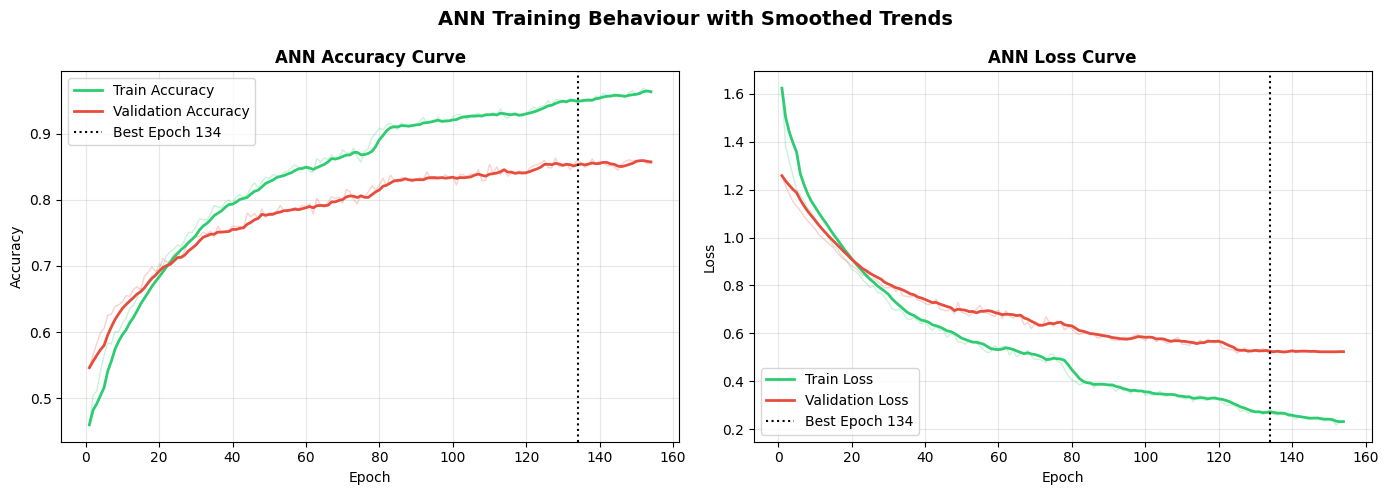

Learning curves saved.


In [23]:

# ============================================================
# Section: ANN Training History - Learning Curves
# ============================================================
# The raw curves are kept lightly visible, while the smoothed curves make the
# training trend easier to read. The vertical line marks the best validation loss.

def smooth_curve(values, window=5):
    return pd.Series(values).rolling(window=window, min_periods=1).mean()

best_epoch = int(np.argmin(history.history['val_loss']) + 1)
epochs = np.arange(1, len(history.history['accuracy']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epochs, history.history['accuracy'], color='#2ecc71', alpha=0.25, linewidth=1)
axes[0].plot(epochs, history.history['val_accuracy'], color='#e74c3c', alpha=0.25, linewidth=1)
axes[0].plot(epochs, smooth_curve(history.history['accuracy']), label='Train Accuracy', color='#2ecc71', linewidth=2)
axes[0].plot(epochs, smooth_curve(history.history['val_accuracy']), label='Validation Accuracy', color='#e74c3c', linewidth=2)
axes[0].axvline(best_epoch, color='black', linestyle=':', linewidth=1.5, label=f'Best Epoch {best_epoch}')
axes[0].set_title('ANN Accuracy Curve', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs, history.history['loss'], color='#2ecc71', alpha=0.25, linewidth=1)
axes[1].plot(epochs, history.history['val_loss'], color='#e74c3c', alpha=0.25, linewidth=1)
axes[1].plot(epochs, smooth_curve(history.history['loss']), label='Train Loss', color='#2ecc71', linewidth=2)
axes[1].plot(epochs, smooth_curve(history.history['val_loss']), label='Validation Loss', color='#e74c3c', linewidth=2)
axes[1].axvline(best_epoch, color='black', linestyle=':', linewidth=1.5, label=f'Best Epoch {best_epoch}')
axes[1].set_title('ANN Loss Curve', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('ANN Training Behaviour with Smoothed Trends', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('ann_learning_curves.png', dpi=150)
plt.show()
print("Learning curves saved.")


## Section: ANN Generate Predictions


In [24]:

# ============================================================
# Section: ANN - Generate Predictions
# ============================================================
# The ANN returns one probability per class, so argmax selects the most likely label.
ann_preds = np.argmax(ann_model.predict(X_test_sc), axis=1)
ann_acc   = accuracy_score(y_test_enc, ann_preds)

print(f"ANN Test Accuracy: {ann_acc*100:.2f}%")
print("\n=== ANN Classification Report ===")
print(classification_report(y_test_enc, ann_preds, target_names=le.classes_))


ANN Test Accuracy: 85.96%

=== ANN Classification Report ===
              precision    recall  f1-score   support

  AGGRESSIVE       0.90      0.86      0.88       385
      NORMAL       0.85      0.82      0.83       440
        SLOW       0.84      0.89      0.87       521

    accuracy                           0.86      1346
   macro avg       0.86      0.86      0.86      1346
weighted avg       0.86      0.86      0.86      1346


## Section: ANN Prediction Confidence Analysis


 1/43 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


=== ANN PREDICTION CONFIDENCE ===

Mean confidence across all predictions:   90.31%
Median confidence:                        98.08%
Predictions with >90% confidence:         943 / 1346
Predictions with <60% confidence:         95 / 1346


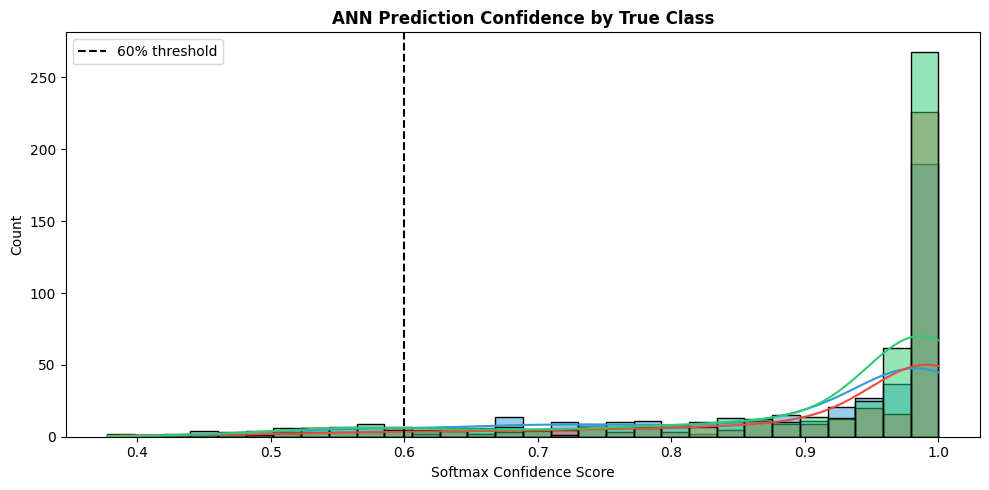

Confidence plot saved.


In [25]:

# ============================================================
# Section: ANN - Prediction Confidence Analysis
# ============================================================
# This checks how confident the ANN is in its predictions, not only whether the
# final class label is correct.
ann_probs = ann_model.predict(X_test_sc)
confidence = ann_probs.max(axis=1)

print("=== ANN PREDICTION CONFIDENCE ===\n")
print(f"Mean confidence across all predictions:   {confidence.mean()*100:.2f}%")
print(f"Median confidence:                        {np.median(confidence)*100:.2f}%")
print(f"Predictions with >90% confidence:         {(confidence > 0.9).sum()} / {len(confidence)}")
print(f"Predictions with <60% confidence:         {(confidence < 0.6).sum()} / {len(confidence)}")

# Plotting confidence by true class helps show where the ANN is uncertain.
conf_df = pd.DataFrame({
    'Confidence':   confidence,
    'True Class':   le.inverse_transform(y_test_enc),
    'Correct':      ann_probs.argmax(axis=1) == y_test_enc
})

plt.figure(figsize=(10, 5))
sns.histplot(data=conf_df, x='Confidence', hue='True Class',
             bins=30, kde=True,
             palette=['#2ecc71', '#e74c3c', '#3498db'])
plt.axvline(0.6, color='black', linestyle='--', label='60% threshold')
plt.title('ANN Prediction Confidence by True Class', fontweight='bold')
plt.xlabel('Softmax Confidence Score')
plt.legend()
plt.tight_layout()
plt.savefig('ann_confidence.png', dpi=150)
plt.show()
print("Confidence plot saved.")


## Section: ANN Evaluation


In [26]:
# ============================================================
# Section: Results — AUC-ROC Comparison (Multi-class)
# ============================================================
# I use AUC scores because accuracy alone doesn't capture how
# well-calibrated each model's predictions are across all three classes.
# AUC is calculated per class in a one-vs-rest fashion and then averaged.
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
# I need probability outputs from all models for AUC
# RF and LR have predict_proba; KNN has predict_proba too
rf_probs  = best_rf.predict_proba(X_test_sc)
lr_probs  = lr_model.predict_proba(X_test_sc)
knn_probs = knn_model.predict_proba(X_test_sc)
ann_probs_eval = ann_model.predict(X_test_sc)
auc_scores = {
    'Random Forest': roc_auc_score(y_test_enc, rf_probs,  multi_class='ovr', average='macro'),
    'Logistic Reg':  roc_auc_score(y_test_enc, lr_probs,  multi_class='ovr', average='macro'),
    'KNN':           roc_auc_score(y_test_enc, knn_probs, multi_class='ovr', average='macro'),
    'ANN':           roc_auc_score(y_test_enc, ann_probs_eval, multi_class='ovr', average='macro')
}
print("=== MACRO AUC-ROC SCORES ===\n")
for model, auc in sorted(auc_scores.items(), key=lambda x: x[1], reverse=True):
    print(f"  {model:<20} AUC = {auc:.4f}")
print("\nAUC of 1.0 = perfect separation | 0.5 = random guessing")


=== MACRO AUC ROC SCORES ===

  Random Forest        AUC = 0.9886
  ANN                  AUC = 0.9653
  KNN                  AUC = 0.7992
  Logistic Reg         AUC = 0.7427

AUC of 1.0 = perfect separation | 0.5 = random guessing


## Section: Results & Evaluation — Full Classification Reports


In [27]:
# ============================================================
# Section: Results & Evaluation — Full Classification Reports
# ============================================================
# I print the full classification report for every model
# so I could compare precision, recall, and F1-score per class.
class_names = list(le.classes_)
print("=== BEST RANDOM FOREST (TUNED) ===")
print(classification_report(y_test_enc, best_rf_preds, target_names=class_names))
print("=== LOGISTIC REGRESSION ===")
print(classification_report(y_test_enc, lr_preds, target_names=class_names))
print("=== KNN ===")
print(classification_report(y_test_enc, knn_preds, target_names=class_names))
print("=== ARTIFICIAL NEURAL NETWORK (ANN) ===")
print(classification_report(y_test_enc, ann_preds, target_names=class_names))


=== BEST RANDOM FOREST (TUNED) ===
              precision    recall  f1-score   support

  AGGRESSIVE       0.97      0.91      0.94       385
      NORMAL       0.96      0.89      0.92       440
        SLOW       0.89      0.98      0.93       521

    accuracy                           0.93      1346
   macro avg       0.94      0.93      0.93      1346
weighted avg       0.93      0.93      0.93      1346

=== LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

  AGGRESSIVE       0.67      0.63      0.65       385
      NORMAL       0.43      0.24      0.31       440
        SLOW       0.53      0.74      0.62       521

    accuracy                           0.55      1346
   macro avg       0.54      0.54      0.53      1346
weighted avg       0.54      0.55      0.53      1346

=== KNN ===
              precision    recall  f1-score   support

  AGGRESSIVE       0.82      0.73      0.77       385
      NORMAL       0.69      0.69      0.69       440


## Section: Results — Confusion Matrices (All 4 Models)


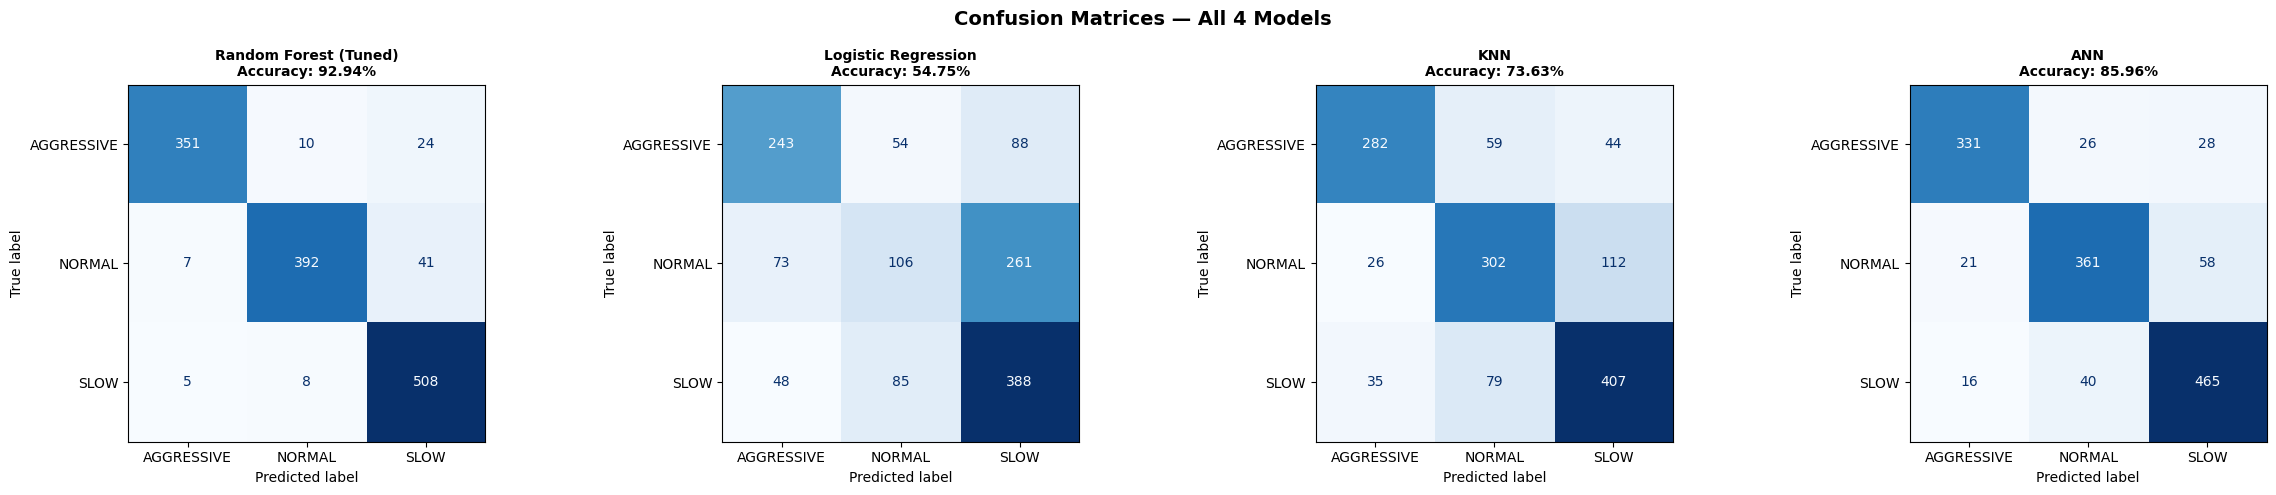

Plot saved.


In [28]:
# ============================================================
# Section: Results — Confusion Matrices (All 4 Models)
# ============================================================
# I plot the four confusion matrices side by side for easier comparison.
# to get a visual sense of where each model struggles.
fig, axes = plt.subplots(1, 4, figsize=(24, 5))
models_info = [
    (best_rf,   best_rf_preds, 'Random Forest (Tuned)'),
    (lr_model,  lr_preds,      'Logistic Regression'),
    (knn_model, knn_preds,     'KNN'),
    (None,      ann_preds,     'ANN')
]
for ax, (model, preds, name) in zip(axes, models_info):
    cm   = confusion_matrix(y_test_enc, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc  = accuracy_score(y_test_enc, preds)
    ax.set_title(f'{name}\nAccuracy: {acc*100:.2f}%',
                 fontweight='bold', fontsize=10)
plt.suptitle('Confusion Matrices — All 4 Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()
print("Plot saved.")


## Section: Results — Model Accuracy Comparison


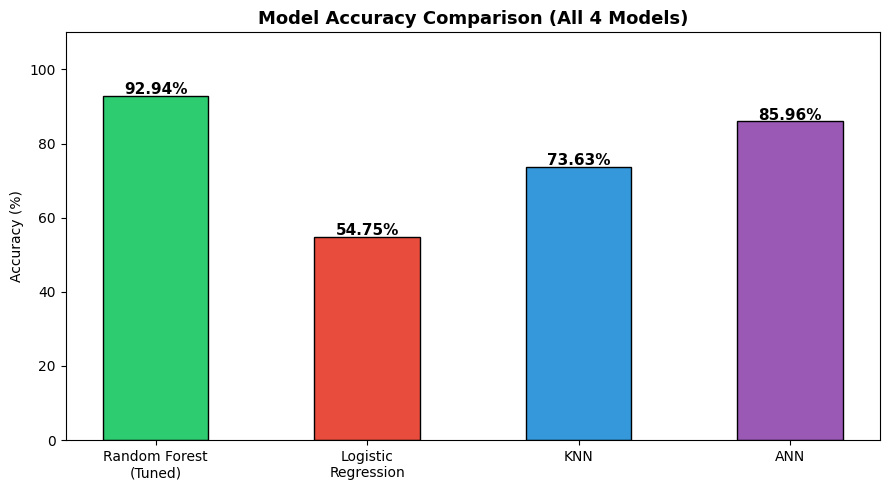

Plot saved.

=== FINAL ACCURACY SUMMARY ===
                 Model  Test Accuracy (%)
Random Forest\n(Tuned)              92.94
                   ANN              85.96
                   KNN              73.63
  Logistic\nRegression              54.75

=== FULL MULTI-METRIC COMPARISON ===


,Model,Accuracy (%),Macro F1,Macro AUC
0,Random Forest,92.94,0.930,0.989
2,ANN,85.96,0.860,0.965
1,KNN,73.63,0.737,0.799
3,Logistic Reg,54.75,0.525,0.743


In [29]:

# ============================================================
# Section: Results - Model Accuracy Comparison Bar Chart
# ============================================================
# This plot gives a quick visual comparison of the four trained models.
plt.figure(figsize=(9, 5))

model_names = ['Random Forest\n(Tuned)', 'Logistic\nRegression', 'KNN', 'ANN']
accuracies  = [best_rf_acc*100, lr_acc*100, knn_acc*100, ann_acc*100]
colors      = ['#2ecc71', '#e74c3c', '#3498db', '#9b59b6']

bars = plt.bar(model_names, accuracies, color=colors,
               edgecolor='black', width=0.5)

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center',
             fontweight='bold', fontsize=11)

plt.ylim(0, 110)
plt.title('Model Accuracy Comparison (All 4 Models)',
          fontweight='bold', fontsize=13)
plt.ylabel('Accuracy (%)')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Plot saved.")

# Accuracy is useful, but F1 and AUC make the comparison more complete.
print("\n=== FINAL ACCURACY SUMMARY ===")
summary = pd.DataFrame({
    'Model': model_names,
    'Test Accuracy (%)': [round(a, 2) for a in accuracies]
}).sort_values('Test Accuracy (%)', ascending=False)
print(summary.to_string(index=False))

from sklearn.metrics import f1_score
print("\n=== FULL MULTI-METRIC COMPARISON ===")
full_summary = pd.DataFrame({
    'Model':            ['Random Forest', 'KNN', 'ANN', 'Logistic Reg'],
    'Accuracy (%)':     [round(best_rf_acc*100,2), round(knn_acc*100,2),
                         round(ann_acc*100,2), round(lr_acc*100,2)],
    'Macro F1':         [round(f1_score(y_test_enc, best_rf_preds, average='macro'),3),
                         round(f1_score(y_test_enc, knn_preds,     average='macro'),3),
                         round(f1_score(y_test_enc, ann_preds,     average='macro'),3),
                         round(f1_score(y_test_enc, lr_preds,      average='macro'),3)],
    'Macro AUC':        [round(auc_scores['Random Forest'],3),
                         round(auc_scores['KNN'],3),
                         round(auc_scores['ANN'],3),
                         round(auc_scores['Logistic Reg'],3)]
}).sort_values('Accuracy (%)', ascending=False)
display(full_summary)


## Section: Appendices — Save Models


In [30]:

# ============================================================
# Section: Appendices - Save Final Models
# ============================================================
# I save the trained models and scaler so they can be reused without retraining.
import joblib
from sklearn.metrics import f1_score

joblib.dump(best_rf, 'best_rf_model.pkl')
joblib.dump(scaler,  'scaler.pkl')
ann_model.save('ann_model.keras')

# The final summary is generated from the variables above, so the numbers stay
# consistent with the notebook run.
print("=== FINAL SUMMARY ===")
print(f"Dataset:          Driver Behaviour ({len(train_df) + len(test_df)} samples, 3 classes)")
print(f"Features used:    {len(all_features)} "
      f"(6 raw + 2 magnitude + 4 jerk + {len(all_features)-12} rolling)")
print(f"Models trained:   Random Forest (Tuned), Logistic Regression, KNN, ANN")
print(f"Best Model:       {'Random Forest' if best_rf_acc >= ann_acc else 'ANN'}")
print(f"RF  Accuracy:     {best_rf_acc*100:.2f}%")
print(f"ANN Accuracy:     {ann_acc*100:.2f}%")
print(f"Macro F1 (RF):    {f1_score(y_test_enc, best_rf_preds, average='macro'):.3f}")
print(f"Macro F1 (ANN):   {f1_score(y_test_enc, ann_preds,     average='macro'):.3f}")
print(f"Macro AUC (RF):   {auc_scores['Random Forest']:.3f}")
print(f"Macro AUC (ANN):  {auc_scores['ANN']:.3f}")


=== FINAL SUMMARY ===
Dataset:          Driver Behaviour (6728 samples, 3 classes)
Features used:    44 (6 raw + 2 magnitude + 4 jerk + 32 rolling)
Models trained:   Random Forest (Tuned), Logistic Regression, KNN, ANN
Best Model:       Random Forest
RF  Accuracy:     92.94%
ANN Accuracy:     85.96%
Macro F1 (RF):    0.930
Macro F1 (ANN):   0.860
Macro AUC (RF):   0.989
Macro AUC (ANN):  0.965
